In [1]:
!pip install pandas textblob seaborn matplotlib wordcloud scikit-learn networkx


In [2]:
import pandas as pd
import numpy as np
import nltk
from textblob import TextBlob
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import networkx as nx
from collections import Counter, defaultdict
import re

In [3]:
#NLTK
nltk.download('punkt')
nltk.download('stopwords')
from nltk.corpus import stopwords

#Load Dataset
data_path = "/content/kaggle_RC_2019-05.csv"
data = pd.read_csv(data_path)
data = data[['body', 'subreddit']].dropna()
print(f"Dataset Loaded: {data.shape[0]} comments from {data['subreddit'].nunique()} subreddits.")



[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


Dataset Loaded: 1000000 comments from 40 subreddits.


In [4]:
#Text Preprocessing
nltk.download('punkt_tab')
stop_words = set(stopwords.words('english'))

def preprocess(text):
    text = str(text).lower()
    text = re.sub(r'[^`-z -� 0-9]+', '', text)
    tokens = nltk.word_tokenize(text)
    tokens = [t for t in tokens if t.isalnum() and t not in stop_words]
    return ' '.join(tokens)

data['cleaned_comments'] = data['body'].apply(preprocess)

#Sentiment Analysis
def get_sentiment(text):
    return TextBlob(text).sentiment.polarity

data['sentiment'] = data['cleaned_comments'].apply(get_sentiment)

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


Top Words: [('like', np.int64(141210)), ('people', np.int64(89889)), ('would', np.int64(89505)), ('one', np.int64(82900)), ('get', np.int64(79959)), ('dont', np.int64(72856)), ('think', np.int64(70252)), ('im', np.int64(61614)), ('time', np.int64(59748)), ('know', np.int64(57291)), ('make', np.int64(55437)), ('even', np.int64(54536)), ('good', np.int64(52911)), ('really', np.int64(49364)), ('see', np.int64(46278)), ('please', np.int64(46155)), ('us', np.int64(43990)), ('post', np.int64(43845)), ('also', np.int64(42147)), ('could', np.int64(40295))]


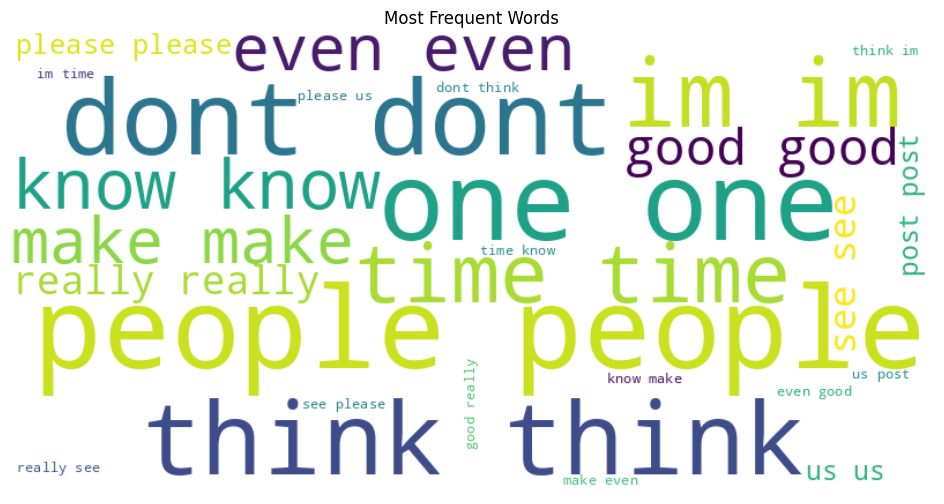

In [5]:
#Lexicon Sentiment
sentiment_dict = {"happy":1, "sad":-1, "excited":2, "angry":-2, "not":-1, "good":1, "bad":-1, "great":2, "terrible":-2}
def lexicon_sentiment(tokens):
    return sum([sentiment_dict.get(word, 0) for word in tokens])

data['lexicon_sentiment'] = data['cleaned_comments'].apply(lambda x: lexicon_sentiment(x.split()))

#Top Words & Wordclouds
def get_top_words(corpus, n=20):
    vec = CountVectorizer().fit(corpus)
    bag = vec.transform(corpus)
    sums = bag.sum(axis=0)
    words_freq = [(word, sums[0, idx]) for word, idx in vec.vocabulary_.items()]
    return sorted(words_freq, key=lambda x:x[1], reverse=True)[:n]

top_words = get_top_words(data['cleaned_comments'], 20)
print("Top Words:", top_words)

#WordCloud Visualization
def generate_wordcloud(words, title):
    wc = WordCloud(width=800, height=400, background_color="white").generate(" ".join(words))
    plt.figure(figsize=(12,6))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(title)
    plt.show()

all_words = [word for word, freq in top_words for _ in range(freq)]
generate_wordcloud(all_words, "Most Frequent Words")

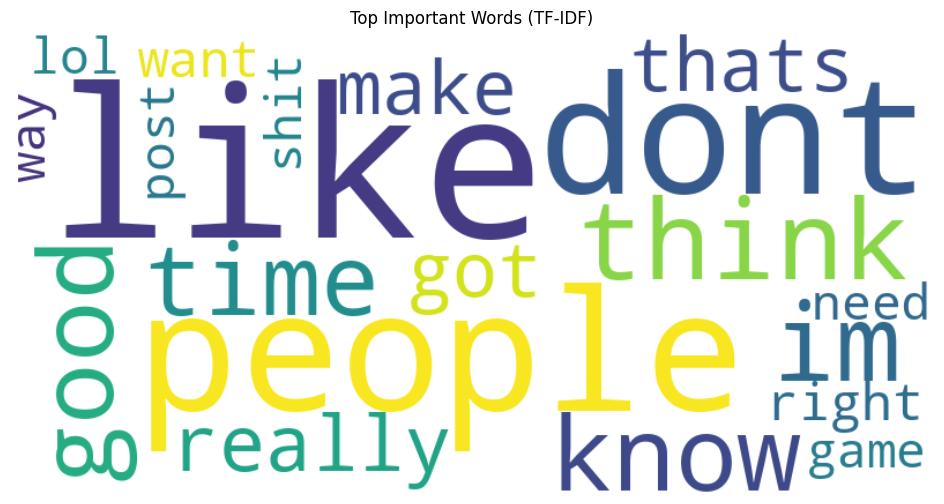

In [7]:
def generate_wordcloud_from_freq(word_freq_list, title):
    # Convert list of (word, score) tuples to a dictionary for WordCloud
    frequencies = {word: score for word, score in word_freq_list}
    wc = WordCloud(width=800, height=400, background_color="white").generate_from_frequencies(frequencies)
    plt.figure(figsize=(12,6))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(title)
    plt.show()

def get_top_tfidf_words(corpus, n=20):
    vec = TfidfVectorizer(stop_words='english')
    X = vec.fit_transform(corpus)

    scores = np.asarray(X.mean(axis=0)).ravel()
    words = vec.get_feature_names_out()

    word_scores = list(zip(words, scores))
    return sorted(word_scores, key=lambda x: x[1], reverse=True)[:n]

top_tfidf_words = get_top_tfidf_words(data['cleaned_comments'], 20)

generate_wordcloud_from_freq(top_tfidf_words, "Top Important Words (TF-IDF)")

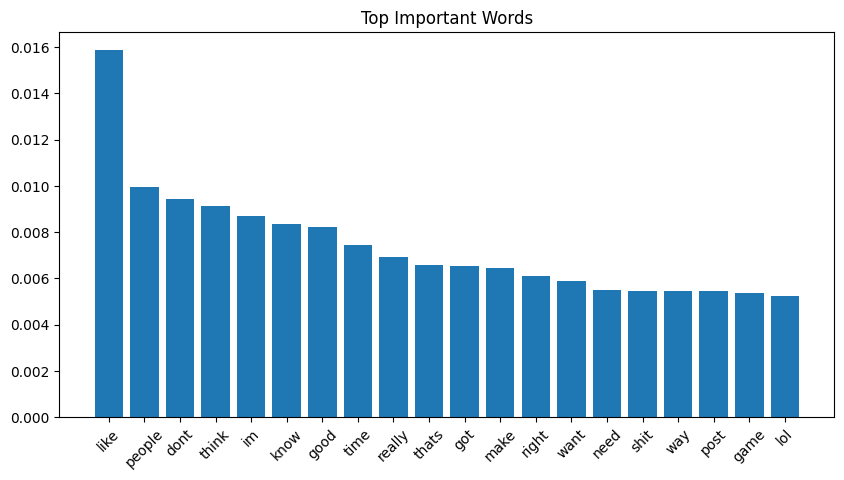

In [8]:
def plot_top_words(word_freq, title):
    words, freqs = zip(*word_freq)

    plt.figure(figsize=(10,5))
    plt.bar(words, freqs)
    plt.xticks(rotation=45)
    plt.title(title)
    plt.show()

plot_top_words(top_tfidf_words, "Top Important Words")

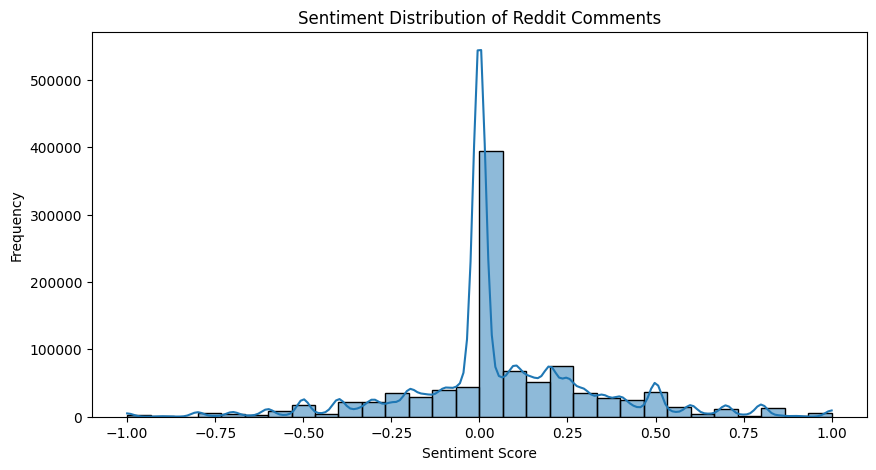

In [10]:
#Sentiment Distribution
plt.figure(figsize=(10,5))
sns.histplot(data['sentiment'], bins=30, kde=True)
plt.title("Sentiment Distribution of Reddit Comments")
plt.xlabel("Sentiment Score")
plt.ylabel("Frequency")
plt.show()


                                                     body  sentiment
481152               You should write 'programming' more.     0.0000
566840               The "not all" programming goes deep.     0.0000
682302     I suppose thats why they call it "programming"     0.0000
380445  Does that mean I can sign up for minority prog...    -0.3125
705200   i cant tell if your bad at soccer or programming    -0.7000
subreddit
gonewild         0.219107
aww              0.125948
Market76         0.096908
marvelstudios    0.084616
movies           0.082889
Name: sentiment, dtype: float64
subreddit
The_Donald    0.027089
news          0.024998
RoastMe       0.024525
trashy        0.019969
Pikabu        0.001684
Name: sentiment, dtype: float64


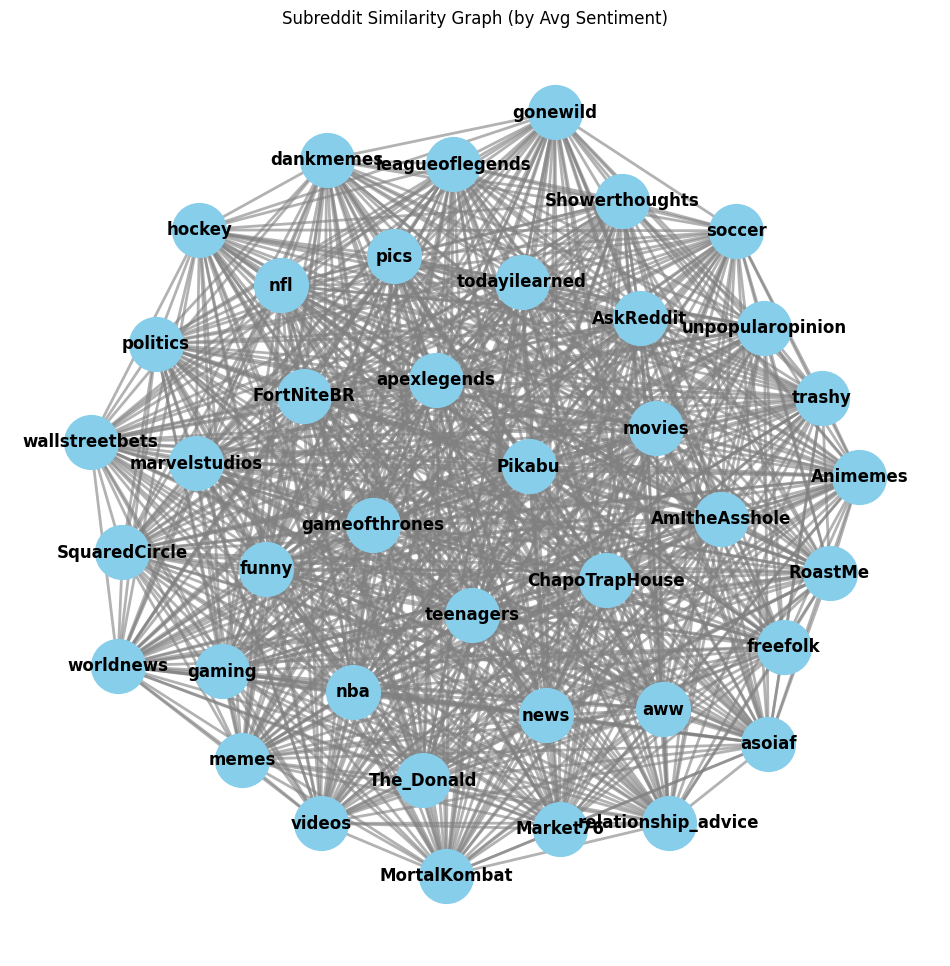

In [11]:
#TF-IDF Recommendation System
tfidf_vectorizer = TfidfVectorizer()
tfidf_matrix = tfidf_vectorizer.fit_transform(data['cleaned_comments'])

def recommend_comments(user_input, top_n=5):
    vec_input = tfidf_vectorizer.transform([preprocess(user_input)])
    cosine_sim = cosine_similarity(vec_input, tfidf_matrix)
    indices = cosine_sim[0].argsort()[-top_n:][::-1]
    return data.iloc[indices][['body', 'sentiment']]

user_input_example = "I love programming"
print(recommend_comments(user_input_example))

#Subreddit Sentiment Aggregation
subreddit_sentiment = data.groupby('subreddit')['sentiment'].mean().sort_values(ascending=False)
print(subreddit_sentiment.head(5))  # Most positive
print(subreddit_sentiment.tail(5))  # Most negative

#Subreddit Similarity Graph
def calculate_similarity_graph(subreddit_sentiment):
    G = nx.Graph()
    subreddits = subreddit_sentiment.index.tolist()
    G.add_nodes_from(subreddits)
    for i, s1 in enumerate(subreddits):
        for s2 in subreddits[i+1:]:
            sim = 1 / (1 + abs(subreddit_sentiment[s1] - subreddit_sentiment[s2]))
            if sim > 0:
                G.add_edge(s1, s2, weight=sim)
    return G

G = calculate_similarity_graph(subreddit_sentiment)
plt.figure(figsize=(12,12))
pos = nx.spring_layout(G, seed=42)
nx.draw_networkx_nodes(G, pos, node_size=1500, node_color='skyblue')
nx.draw_networkx_edges(G, pos, width=2, alpha=0.6, edge_color='gray')
nx.draw_networkx_labels(G, pos, font_size=12, font_weight='bold')
plt.title("Subreddit Similarity Graph (by Avg Sentiment)")
plt.axis('off')
plt.show()